# Evaluation of Experiments

In [1]:
# Some imports and general information

import mlflow
import numpy as np
import pandas as pd
import pylab as plt
import seaborn as sns
from IPython.display import display

# Command to sync the database
# rsync -avz cluster.ies:/mnt/stud/work/phahn/repositories/dal-toolbox/perf_dal_new.db /home/phahn/repositories/dal-toolbox/publications/perf_dal/notebooks/paul/perf_dal_new.db

# Command to sync the artifacts
# rsync -ravz cluster.ies:/mnt/stud/work/phahn/repositories/dal-toolbox/dal-toolbox/publications/perf_dal/slurm/paul/mlruns/ /home/phahn/repositories/dal-toolbox/publications/perf_dal/notebooks/paul/mlruns/

# Datasets
datasets = {
    'cifar10': {'qs':10, 'n':'CIFAR10'}, 
    'stl10':{'qs':10, 'n':'STL10'}, 
    'snacks':{'qs':20, 'n':'SNACKS'}, 
    'flowers102':{'qs':25, 'n':'Flowers102'}, 
    'dtd':{'qs':50, 'n':'DTD'}, 
    'food101':{'qs':100, 'n':'Food101'}, 
    'cifar100':{'qs':100, 'n':'CIFAR100'},
    'tiny_imagenet':{'qs':200, 'n': 'TinyImageNet'},
    'imagenet':{'qs':1000, 'n':'ImageNet'},
    'dopanim':{'qs':25, 'n':'Dopanim'}
    }

# Query Strategies
query_strategies = {
    'alfamix':{'n':'AlfaMix', 'c':'red', 'ls':'-'},
    'badge':{'n':'BADGE', 'c':'blue', 'ls':'-'},
    'bait':{'n':'BAIT', 'c':'green', 'ls':'-'},
    'coreset':{'n':'CoreSet', 'c':'purple', 'ls':'-'},
    'dropquery':{'n':'DropQuery', 'c':'orange', 'ls':'-'},
    'margin':{'n':'Margin', 'c':'cyan', 'ls':'-'},
    'random':{'n':'Random', 'c':'black', 'ls':'-'},
    'typiclust':{'n':'Typiclust', 'c':'pink', 'ls':'-'},

    'lazy+vary oracle(11)':{'n':'Our Approach (11)', 'c':'red', 'ls':'-'},
    'lazy+vary oracle(55)':{'n':'Our Approach (55)', 'c':'red', 'ls':'--'},
    'lazy+vary oracle(110)':{'n':'Our Approach (110)', 'c':'red', 'ls':'-.'},
    'lazy+vary oracle(220)':{'n':'Our Approach (220)', 'c':'red', 'ls':':'},

    'naive oracle(11)':{'n':'Naive (11)', 'c':'blue', 'ls':'-'},
    'naive oracle(55)':{'n':'Naive (55)', 'c':'blue', 'ls':'--'},
    'naive oracle(110)':{'n':'Naive (110)', 'c':'blue', 'ls':'-.'},
    'naive oracle(220)':{'n':'Naive (220)', 'c':'blue', 'ls':':'},

    'Naive Oracle (5 epochs)':{'n':'5 Epochs', 'c':'red', 'ls':'--'},
    'Naive Oracle (10 epochs)':{'n':'10 Epochs', 'c':'blue', 'ls':'--'},
    'Naive Oracle (25 epochs)':{'n':'25 Epochs', 'c':'green', 'ls':'--'},
    'Naive Oracle (50 epochs)':{'n':'50 Epochs', 'c':'yellow', 'ls':'--'},
    'Naive Oracle (75 epochs)':{'n':'75 Epochs', 'c':'cyan', 'ls':'--'},
    'Naive Oracle (100 epochs)':{'n':'100 Epochs', 'c':'pink', 'ls':'--'},
    'Naive Oracle (150 epochs)':{'n':'150 Epochs', 'c':'orange', 'ls':'--'},
    'Naive Oracle (200 epochs)':{'n':'200 Epochs', 'c':'black', 'ls':'-'},

    'Naive Oracle (perf_est=brier)':{'n':'Brier Score', 'c':'pink', 'ls':'--'},
    'Naive Oracle (perf_est=zero_one)':{'n':'Zero One', 'c':'orange', 'ls':'--'},
    'Naive Oracle (perf_est=cross_entropy)':{'n':'Cross Entropy', 'c':'black', 'ls':'--'},

    'Naive Oracle (acq_size=S)':{'n':'S', 'c':'green', 'ls':'-'},
    'Naive Oracle (acq_size=M)':{'n':'M', 'c':'orange', 'ls':'-'},
    'Naive Oracle (acq_size=L)':{'n':'L', 'c':'blue', 'ls':'-'},
    'Naive Oracle (acq_size=XL)':{'n':'XL', 'c':'red', 'ls':'-'},

    'Oracle (-0)':{'n':'Oracle (-0)', 'c':'blue', 'ls':'-'},
    'Oracle (-1)':{'n':'Oracle (-1)', 'c':'green', 'ls':'-'}
}

sampling_strategies = ['randomsampling', 'typiclust', 'dropquery', 'baitsampling', 'alfamix', 'badge', 'coreset', 'marginsampling', 'typiclass', 'losssampling', 'dropqueryclass']

# Load in all results
all_acc_curves_strategies = {}
all_pick_choices = {}
query_times = {}

# Mlflow args
uri = 'sqlite:///perf_dal_new.db'
client = mlflow.tracking.MlflowClient(tracking_uri=uri)

def style_negative(v, props=''):
    return props if v.count('-') > 1 else None

def df_style(val):
    return "font-weight: bold"

In [2]:
# To read in data (removes duplicate code)
def retrieve_data(all_acc_curves_strategies, query_times, all_pick_choices, client, run, key, sampling_strategies, get_pick_choices=True):
    accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
    qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]
    dataset = run.data.params['dataset_name']
    seed = run.data.params['random_seed']
    
    if str(len(accs)-1) == run.data.params['al.num_acq']: # Sorts out runs that accidentally did not track all cycles
        # Save Accuracies
        if dataset not in all_acc_curves_strategies:
            all_acc_curves_strategies[dataset] = {}
        if key not in all_acc_curves_strategies[dataset]:
            all_acc_curves_strategies[dataset][key] = {}
        all_acc_curves_strategies[dataset][key][seed] = accs

        # Save Query Times
        if dataset not in query_times:
            query_times[dataset] = {}
        if key not in query_times[dataset]:
            query_times[dataset][key] = {}
        query_times[dataset][key][seed] = qts

        # Save Pick Choices
        if get_pick_choices:
            pick_choices = {k : client.get_metric_history(run.info.run_id, f'bought_{k}') for k in sampling_strategies}
            if dataset not in all_pick_choices:
                all_pick_choices[dataset] = {}
            if key not in all_pick_choices[dataset]:
                all_pick_choices[dataset][key] = {}
            all_pick_choices[dataset][key][seed] = pick_choices
    else:
        print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])
    
    return all_acc_curves_strategies, query_times, all_pick_choices

In [3]:
# Plotting functions for a pairwise comparison in one dset, averaged over all dsets and a global comparison
def plot_learning_curves(all_acc_curves_strategies, strats, dsets, query_strategies, datasets, baseline="random", nrows=1, ncols=2, figsize=(10,4), only_tables=False, legend_dist=1.225):
    if not only_tables:
        fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, tight_layout=True)
    auc_values_rel = {}
    final_acc_rel = {}
    auc_values_abs = {}
    final_acc_abs = {}
    for i, dset in enumerate(dsets):
        auc_values_rel[dset] = {}
        final_acc_rel[dset] = {}
        auc_values_abs[dset] = {}
        final_acc_abs[dset] = {}

        rand_accs = list(all_acc_curves_strategies[dset][baseline].values()) 
        avg_rand_accs = np.mean(rand_accs, axis=0)
        rand_auc = np.mean(rand_accs, axis=1)
        rand_final_accs = [ac[-1]*100 for ac in rand_accs]
        rand_auc_mean, rand_auc_std = np.mean(rand_auc), np.std(rand_auc) / np.sqrt(rand_auc.shape[0])
        rand_acc_mean, rand_acc_std = np.mean(rand_final_accs), np.std(rand_final_accs) / np.sqrt(len(rand_final_accs))
        auc_values_rel[dset][baseline] = str(rand_auc_mean.round(4)) + '+/-' + str(rand_auc_std.round(4))
        final_acc_rel[dset][baseline] = str(rand_acc_mean.round(2)) + '+/-' + str(rand_acc_std.round(2))
        auc_values_abs[dset][baseline] = str(rand_auc_mean.round(4)) + '+/-' + str(rand_auc_std.round(4))
        final_acc_abs[dset][baseline] = str(rand_acc_mean.round(2)) + '+/-' + str(rand_acc_std.round(2))
        if not only_tables:
            if nrows == 1:
                plt.axes(ax[i])
            else:
                plt.axes(ax[i%nrows][i//nrows])
            
        n_labeled_samples = [j*datasets[dset]['qs'] + datasets[dset]['qs'] for j in range(21)]
        for qs in all_acc_curves_strategies[dset]:
            if qs in strats:
                accs = list(all_acc_curves_strategies[dset][qs].values())
                avg_accs = np.mean(accs, axis=0)
                final_accs = [ac[-1]*100 for ac in accs]
                aucs = np.mean(accs, axis=1)
                aucs_mean, aucs_std  = np.mean(aucs), np.std(aucs) / np.sqrt(aucs.shape[0])
                final_acc_mean, final_acc_std = np.mean(final_accs), np.std(final_accs) / np.sqrt(len(final_accs))

                if qs != baseline:
                    auc_values_rel[dset][qs] = str((aucs_mean - rand_auc_mean).round(4)) + '+/-' + str(aucs_std.round(4))
                    final_acc_rel[dset][qs] = str((final_acc_mean - rand_acc_mean).round(2)) + '+/-' + str(final_acc_std.round(2))
                    auc_values_abs[dset][qs] = str((aucs_mean).round(4)) + '+/-' + str(aucs_std.round(4))
                    final_acc_abs[dset][qs] = str((final_acc_mean).round(2)) + '+/-' + str(final_acc_std.round(2))
                if not only_tables:
                    plt.plot(n_labeled_samples, avg_accs - avg_rand_accs, c=query_strategies[qs]['c'], label=query_strategies[qs]['n'], linestyle=query_strategies[qs]['ls'])
        if not only_tables:
            plt.xlabel('Labeled Samples')
            if i//nrows == 0:
                plt.ylabel('Relative Test Accuracy \n Improvement (%)')
            plt.grid(True)
            plt.title(datasets[dset]['n'])
            plt.xlim(datasets[dset]['qs'], 20*datasets[dset]['qs'])
    if not only_tables:
        handles, labels = plt.gca().get_legend_handles_labels()
        fig.legend(loc="right", bbox_to_anchor=[legend_dist, .5], handles=handles, labels=labels)
        plt.show()
    return {
        'acc_rel':final_acc_rel,
        'acc_abs':final_acc_abs,
        'auc_rel':auc_values_rel,
        'auc_abs':auc_values_abs
    }

def plot_global_pairwise_comparison(results, dsets, strategies, Labels, figsize=(6,5)):
    # Compute win rates
    win_rates = pd.DataFrame(index=strategies, columns=strategies)
    for strat1 in strategies:
        for strat2 in strategies:
            if strat1 == strat2:
                win_rates.loc[strat1, strat2] = 0.0
            else:
                accs1, accs2 = [], []
                for dset in dsets:
                    for key in results[dset][strat1]:
                        accs1.append(results[dset][strat1][key])
                        accs2.append(results[dset][strat2][key])
                means1 = np.mean(accs1, axis=1)
                means2 = np.mean(accs2, axis=1)

                assert means1.shape == means2.shape, f'On {dset}, {strat1} and {strat2} do not have the same number of results'
                
                comparisons = means1.round(4) > means2.round(4)
                wins = np.sum(comparisons) / means1.shape[0]
                win_rates.loc[strat1, strat2] = wins
    win_rates.index = [strat.capitalize() for strat in win_rates.index]
    win_rates.columns = [strat.capitalize() for strat in win_rates.columns]

    # Plot the heatmap
    #win_rates = win_rates.sort_index(axis=0)
    #win_rates = win_rates.sort_index(axis=1)
    plt.figure(figsize=figsize)
    sns.heatmap(win_rates.astype(float).T, annot=True, fmt=".2f", cmap="coolwarm", center=.50, xticklabels=Labels, yticklabels=Labels)
    plt.title(f"Global Pairwise Comparison")
    plt.ylabel("Challenged Strategy")
    plt.xlabel("Challenging Strategy")
    plt.tight_layout()
    plt.show() 


def plot_global_comparison(results, dsets, strategies, Labels, figsize=(6,5)):
    # Compute win rates
    win_rates = pd.DataFrame(index=dsets, columns=strategies)
    for dset in dsets:
        for strat1 in strategies:
            accs1 = []
            for key in results[dset][strat1]:
                accs1.append(results[dset][strat1][key])
            means1 = np.mean(accs1, axis=1)
            comparisons = []
            for strat2 in strategies:
                if strat2 != strat1:
                    accs2 = []
                    for key in results[dset][strat1]:
                        accs2.append(results[dset][strat2][key])
                    means2 = np.mean(accs2, axis=1)
                    comparison = means1.round(4) > means2.round(4)
                    comparisons.append(comparison)
            comp = np.prod(comparisons, axis=0)
            wins = np.sum(comp) / means1.shape[0]
            win_rates.loc[dset, strat1] = wins

    win_rates.index = [dset.capitalize() for dset in win_rates.index]
    win_rates.columns = [strat.capitalize() for strat in win_rates.columns]

    # Plot the heatmap
    #win_rates = win_rates.sort_index(axis=0)
    #win_rates = win_rates.sort_index(axis=1)

    plt.figure(figsize=figsize)
    plt.title(f"Highest AUC per Dataset (%)")
    sns.heatmap(win_rates.astype(float), annot=True, fmt=".2f", cmap="coolwarm", center=.50, xticklabels=Labels)
    plt.ylabel("Dataset")
    plt.xlabel("Strategy")
    plt.tight_layout()
    plt.show()



def plot_avg_pick_choices(all_pick_choices, fig_strats, fig_dsets, sampling_strategies, figsize=(12, 5), cmap = 'viridis', n_queries = 20):
    n_plots = len(fig_dsets) * len(fig_strats)

    fig, ax = plt.subplots(nrows=1, ncols=n_plots + 1, figsize=figsize, width_ratios=[1 for _ in range(n_plots)]+ [.2])
    fig.suptitle("Average Pick Choice")
    imshows = []

    for a, dset in enumerate(fig_dsets):
        for b, strat in enumerate(fig_strats):     
            j = a + b * len(fig_dsets)
            vmin, vmax = 1, 0
            
            image = []
            for sampl_strat in sampling_strategies:
                img = []
                for seed in range(1, 11):
                    seed = str(seed)
                    im = []
                    for i in range(1, n_queries):
                        if sampl_strat in all_pick_choices[dset][strat][seed] and all_pick_choices[dset][strat][seed][sampl_strat] != []:
                            im.append(1 if (all_pick_choices[dset][strat][seed][sampl_strat][i].value > all_pick_choices[dset][strat][seed][sampl_strat][i-1].value) else 0)
                        else:
                            im.append(0)
                    img.append(im)
                image.append(img)
            image = np.array(image)
            img = np.mean(image, axis=1)
            img_avg = np.mean(img, axis=-1, keepdims=True)

            vmin, vmax = min(vmin, min(img_avg)), max(vmax, max(img_avg))

            c1 = ax[j].imshow(img_avg, vmin=vmin, vmax=vmax, cmap=cmap)
            imshows.append(c1)

            for (i, k), val in np.ndenumerate(img_avg):
                ax[j].text(k, i, f"{val:.2f}" if f"{val:.2f}" != "0.00" else "X", ha='center', va='center', color='white')
            ax[j].set_xticks(ticks=[0], labels=[strat], rotation=25)

            if j == 0:
                ax[j].set_yticks(ticks=range(len(sampling_strategies)), labels=sampling_strategies)
            else:
                ax[j].set_yticks([])
            ax[j].set_title(dset)

    for im in imshows:
        im.set_clim(vmin=vmin, vmax=vmax)

    fig.colorbar(im, cax=ax[-1])
    plt.show()


def plot_avg_pick_choices_dset(all_pick_choices, strat, dsets, sampling_strategies, figsize=(14, 5), cmap='viridis', title=None):
    fig = plt.figure(figsize=figsize)
    if title:
        fig.suptitle(title)
    
    n_queries = 20
    images = []
    for dset in dsets:
        image = []
        for sampl_strat in sampling_strategies:
            img = []
            for seed in all_pick_choices[dset][strat]:
                im = []
                for i in range(1, n_queries+1):
                    if sampl_strat in all_pick_choices[dset][strat][seed] and len(all_pick_choices[dset][strat][seed][sampl_strat])>0:
                        if i == 0:
                            im.append(all_pick_choices[dset][strat][seed][sampl_strat][i].value)
                        else:
                            im.append(1 if (all_pick_choices[dset][strat][seed][sampl_strat][i].value > all_pick_choices[dset][strat][seed][sampl_strat][i-1].value) else 0)
                    else:
                        im.append(0)
                img.append(im)
            image.append(img)
        images.append(image)
    images = np.array(images)
    img = np.mean(np.mean(images, axis=0), axis=1)

    c1 = plt.imshow(img, cmap=cmap)

    plt.xticks(ticks=range(20), labels=range(1,21), rotation=0)
    plt.yticks(ticks=range(len(sampling_strategies)), labels=sampling_strategies)

    plt.title('Avg. Pick Choice over all Datasets')
    plt.colorbar(c1)
    plt.show()

## Experiment 1 - Baselines

The first experiment contains the runs including well-known DAL-strategies on a variety of different Datasets. These include:

Datasets = [CIFAR10, CIFAR100, STL10, Snacks, DTD, Food101, Flowers102, TinyImageNet, ImageNet, Dopanim]

DAL Query Strategiges = [AlfaMix, BADGE, BAIT, CoreSet, DropQuery, Margin, Random, Typiclust]

In [4]:
experiment_name = 'dinov2_baselines'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 10 * 10 * 8)) # n_dsets * n_seeds * n_query_strategies

for run in runs_strategies:
    if 'al.strategy' in run.data.params: # This sorts out weird empty runs in the db file
        key = run.data.params['al.strategy']
        all_acc_curves_strategies, query_times, all_pick_choices = retrieve_data(all_acc_curves_strategies, query_times, all_pick_choices, client, run, key, sampling_strategies, get_pick_choices=False)

##################################### dinov2_baselines #####################################
Found 800 experiments for dinov2_baselines with expected 800 experiments.


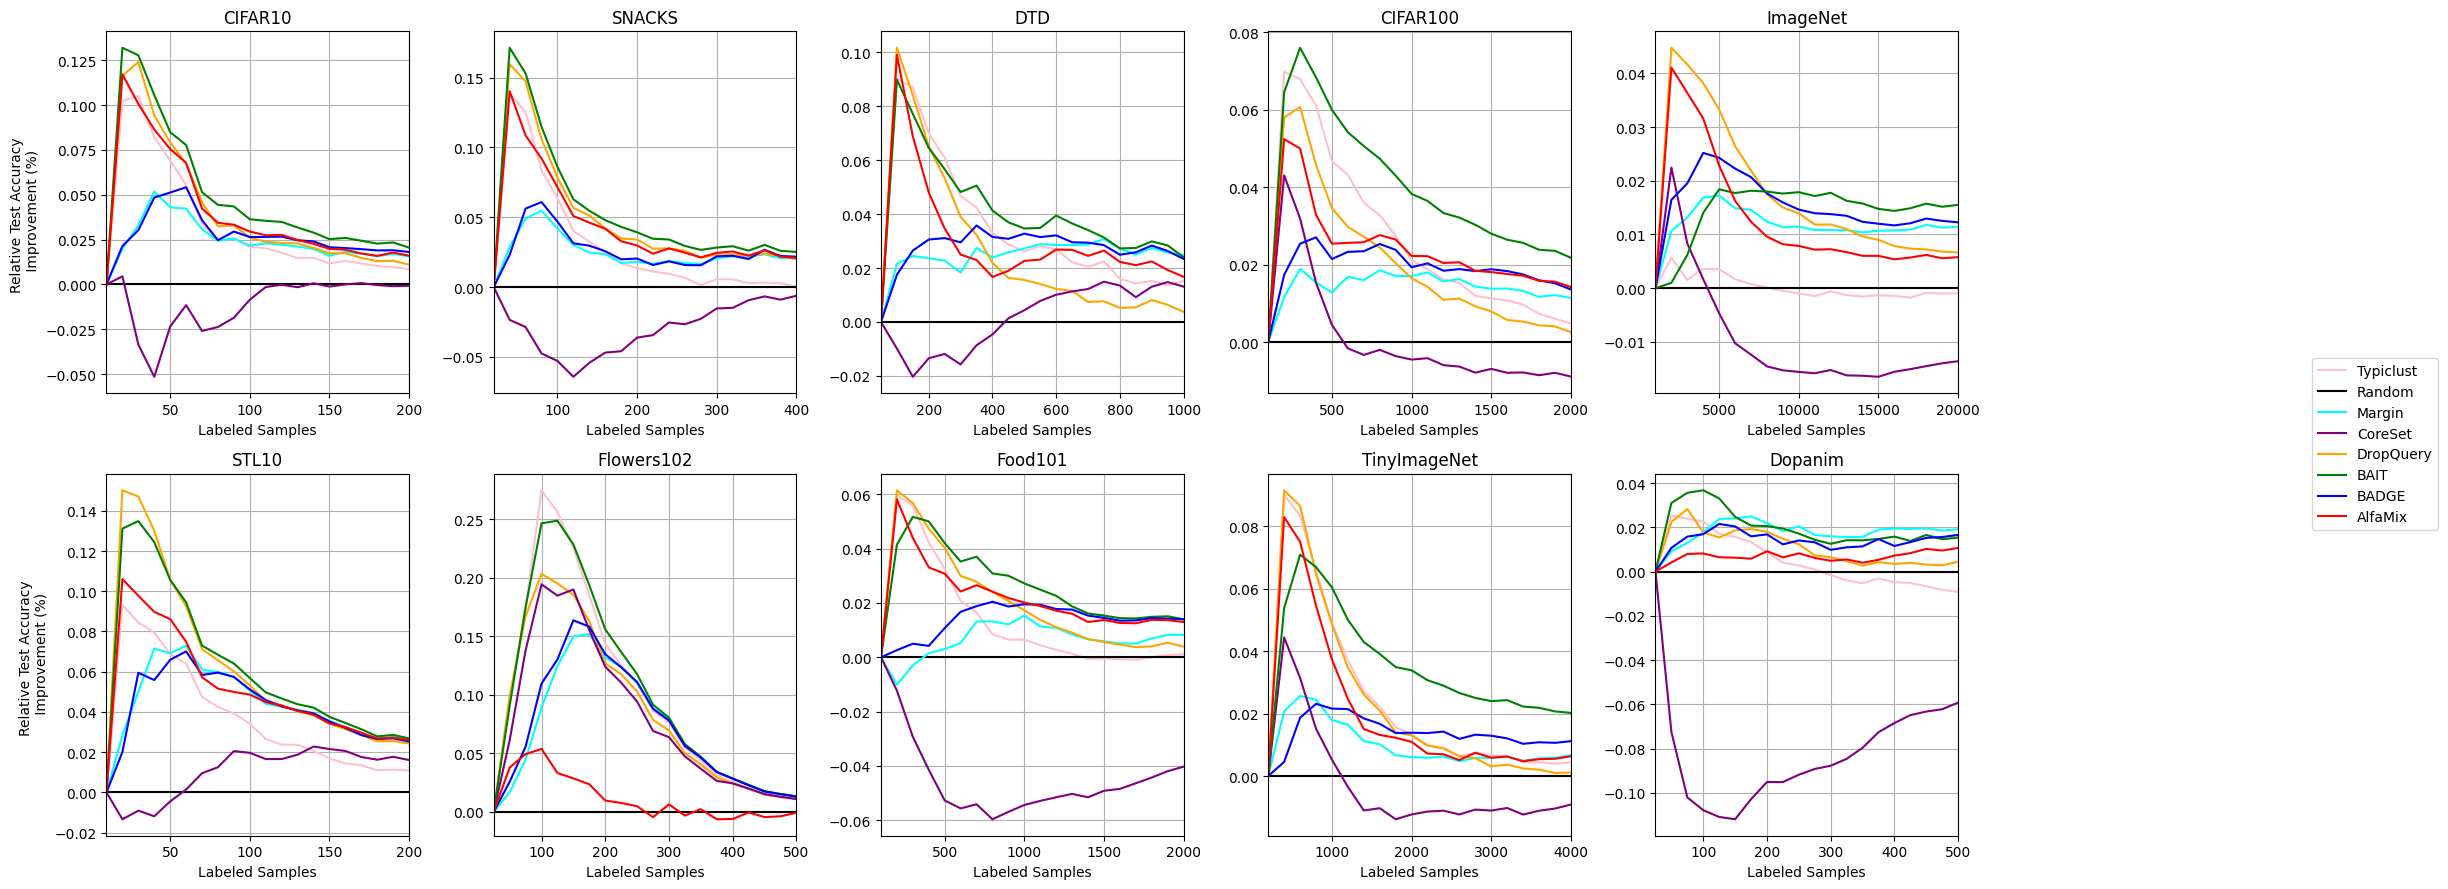

##################################### Final Test-Accuracies (Relative to Random) #####################################


,cifar10,stl10,snacks,flowers102,dtd,food101,cifar100,tiny_imagenet,imagenet,dopanim
random,92.48+/-0.31,96.39+/-0.2,89.42+/-0.13,98.35+/-0.21,74.37+/-0.19,77.92+/-0.15,76.99+/-0.09,72.93+/-0.1,70.37+/-0.04,78.06+/-0.17
typiclust,0.72+/-0.14,0.99+/-0.07,0.05+/-0.2,0.78+/-0.04,1.35+/-0.16,0.13+/-0.14,0.41+/-0.11,0.34+/-0.1,-0.12+/-0.04,-0.92+/-0.15
margin,1.55+/-0.17,2.55+/-0.03,1.95+/-0.14,1.01+/-0.02,2.28+/-0.14,0.8+/-0.15,0.99+/-0.1,0.65+/-0.15,1.17+/-0.05,2.04+/-0.2
dropquery,1.04+/-0.09,2.3+/-0.03,1.72+/-0.17,0.82+/-0.05,0.46+/-0.15,0.35+/-0.12,0.19+/-0.1,0.0+/-0.07,0.65+/-0.04,0.37+/-0.2
coreset,0.11+/-0.23,1.62+/-0.09,-0.38+/-0.34,0.79+/-0.04,1.05+/-0.21,-3.84+/-0.17,-0.9+/-0.07,-0.87+/-0.11,-1.31+/-0.08,-5.84+/-0.27
bait,2.01+/-0.07,2.61+/-0.02,2.3+/-0.12,0.98+/-0.02,2.09+/-0.09,1.35+/-0.13,2.08+/-0.09,1.95+/-0.09,1.55+/-0.05,1.79+/-0.14
badge,1.75+/-0.11,2.43+/-0.03,2.05+/-0.17,0.98+/-0.02,2.25+/-0.1,1.37+/-0.11,1.38+/-0.09,1.02+/-0.08,1.19+/-0.06,1.47+/-0.1
alfamix,1.64+/-0.1,2.47+/-0.04,1.9+/-0.08,-0.2+/-0.15,1.48+/-0.1,1.32+/-0.05,1.39+/-0.08,0.63+/-0.12,0.58+/-0.04,1.2+/-0.17


##################################### Test-AUCs (Relative to Random) #####################################


,cifar10,stl10,snacks,flowers102,dtd,food101,cifar100,tiny_imagenet,imagenet,dopanim
random,0.842+/-0.0042,0.8841+/-0.0041,0.8217+/-0.0025,0.8033+/-0.0058,0.653+/-0.0018,0.6777+/-0.0015,0.6683+/-0.0016,0.6323+/-0.001,0.6197+/-0.0003,0.7109+/-0.0026
typiclust,0.0314+/-0.0025,0.0351+/-0.0019,0.028+/-0.0013,0.094+/-0.0015,0.033+/-0.0015,0.0123+/-0.0015,0.0249+/-0.0011,0.0223+/-0.0009,0.0001+/-0.0003,0.0037+/-0.0022
margin,0.0235+/-0.0034,0.0424+/-0.0021,0.0241+/-0.0025,0.0645+/-0.0036,0.0245+/-0.0019,0.0064+/-0.0023,0.014+/-0.0017,0.0097+/-0.0007,0.0116+/-0.0007,0.0177+/-0.001
dropquery,0.0384+/-0.0013,0.0588+/-0.0015,0.0459+/-0.0015,0.0819+/-0.0013,0.0246+/-0.0012,0.0189+/-0.0009,0.0188+/-0.0006,0.0212+/-0.0007,0.0166+/-0.0005,0.0102+/-0.0013
coreset,-0.0093+/-0.0068,0.0108+/-0.0021,-0.0274+/-0.0037,0.0756+/-0.0012,0.0025+/-0.002,-0.0443+/-0.0026,-0.0001+/-0.0012,-0.0035+/-0.0015,-0.0098+/-0.0009,-0.08+/-0.0034
bait,0.0475+/-0.0021,0.0594+/-0.0015,0.0517+/-0.0011,0.0958+/-0.001,0.0397+/-0.0013,0.0252+/-0.0016,0.0383+/-0.0008,0.0341+/-0.0008,0.0144+/-0.0005,0.0192+/-0.002
badge,0.0266+/-0.0034,0.0412+/-0.0023,0.0255+/-0.0021,0.0677+/-0.0025,0.0271+/-0.0019,0.0135+/-0.0011,0.0188+/-0.0009,0.0135+/-0.0009,0.015+/-0.0005,0.0139+/-0.0015
alfamix,0.0387+/-0.0021,0.0491+/-0.0049,0.0415+/-0.0015,0.0107+/-0.0057,0.0286+/-0.0017,0.021+/-0.0011,0.023+/-0.0011,0.0187+/-0.0011,0.0121+/-0.0005,0.007+/-0.0015


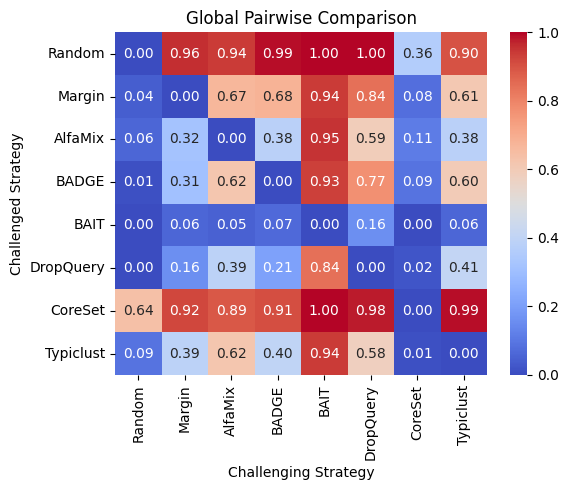

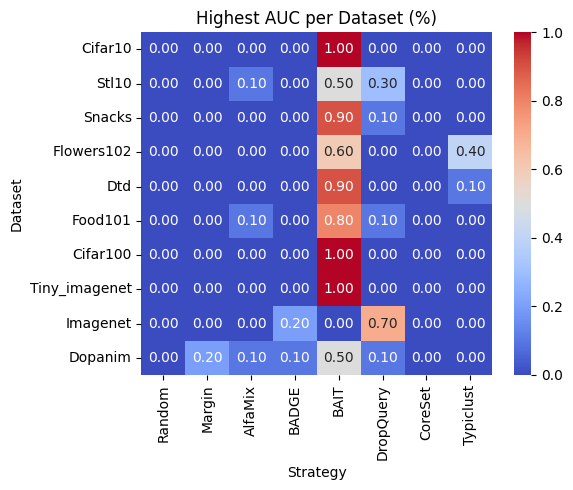

In [5]:
strategies = ['random', 'margin', 'alfamix', 'badge', 'bait', 'dropquery', 'coreset', 'typiclust']
Labels = [query_strategies[strat]['n'] for strat in strategies]
dsets = datasets

res_dic = plot_learning_curves(all_acc_curves_strategies, strats=strategies, dsets=dsets, datasets=datasets, query_strategies=query_strategies, nrows=2, ncols=5, figsize=(20, 9))
final_acc_rel, auc_values_rel, final_acc_abs, auc_values_abs = res_dic['acc_rel'], res_dic['auc_rel'], res_dic['acc_abs'], res_dic['auc_abs']

print('##################################### Final Test-Accuracies (Relative to Random) #####################################')
df = pd.DataFrame(final_acc_rel)
random_row = pd.IndexSlice[df.index[df.index == "random"], :]
s = df.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s)

print('##################################### Test-AUCs (Relative to Random) #####################################')
df2 = pd.DataFrame(auc_values_rel)
random_row = pd.IndexSlice[df.index[df.index == "random"], :]
s2 = df2.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s2)

plot_global_pairwise_comparison(all_acc_curves_strategies, dsets, strategies, Labels=Labels)
plot_global_comparison(all_acc_curves_strategies, dsets, strategies, Labels=Labels)

# Oracle Base Ablations

This section investigates base settings about the oracle model. In particular, we investigate the acq_size, the retraining epochs and the performance estimation to find an optimal setting. The setting we test this in is the Naive Oracle with 50 batches for efficiency.

Order:
1. Num Retraining Epochs
2. ACQ Size
3. Performance Estimation

## Num Retraining Epochs

In [6]:
experiment_name = 'abl_retraining_epochs'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 2 * 10 * 8)) # n_dsets * n_seeds * n_n_epochs

for run in runs_strategies:
    if 'al.strategy' in run.data.params: # This sorts out weird empty runs in the db file
        n_ep = run.data.params['al.optimal.num_retraining_epochs']
        key = f'Naive Oracle ({n_ep} epochs)'
        all_acc_curves_strategies, query_times, all_pick_choices = retrieve_data(all_acc_curves_strategies, query_times, all_pick_choices, client, run, key, sampling_strategies, get_pick_choices=True)

##################################### abl_retraining_epochs #####################################
Found 160 experiments for abl_retraining_epochs with expected 160 experiments.


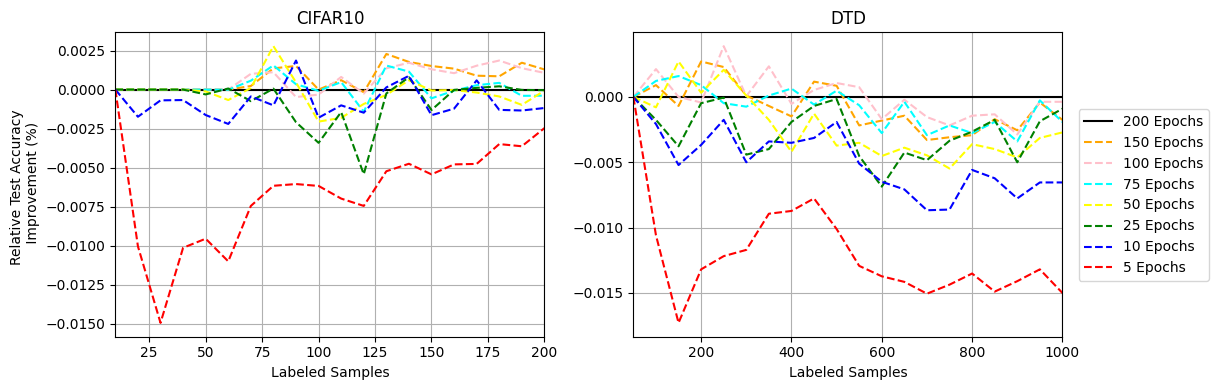

##################################### Final Test-Accuracies (Relative to Random) #####################################


,cifar10,dtd
Naive Oracle (200 epochs),94.51+/-0.06,77.54+/-0.15
Naive Oracle (150 epochs),0.11+/-0.1,-0.02+/-0.17
Naive Oracle (100 epochs),0.1+/-0.06,-0.0+/-0.14
Naive Oracle (75 epochs),0.05+/-0.04,0.04+/-0.14
Naive Oracle (50 epochs),-0.0+/-0.09,-0.11+/-0.08
Naive Oracle (25 epochs),0.02+/-0.04,-0.08+/-0.11
Naive Oracle (10 epochs),-0.11+/-0.06,-0.55+/-0.18
Naive Oracle (5 epochs),-0.31+/-0.06,-1.46+/-0.2


##################################### Test-AUCs (Relative to Random) #####################################


,cifar10,dtd
Naive Oracle (200 epochs),0.8852+/-0.0017,0.6936+/-0.0014
Naive Oracle (150 epochs),0.0008+/-0.0016,-0.0008+/-0.0013
Naive Oracle (100 epochs),0.0007+/-0.0015,-0.0001+/-0.0014
Naive Oracle (75 epochs),0.0002+/-0.0016,-0.0007+/-0.0016
Naive Oracle (50 epochs),-0.0002+/-0.0015,-0.0023+/-0.0014
Naive Oracle (25 epochs),-0.0006+/-0.0015,-0.0026+/-0.0012
Naive Oracle (10 epochs),-0.0008+/-0.0013,-0.0049+/-0.0019
Naive Oracle (5 epochs),-0.0064+/-0.0017,-0.0122+/-0.0018


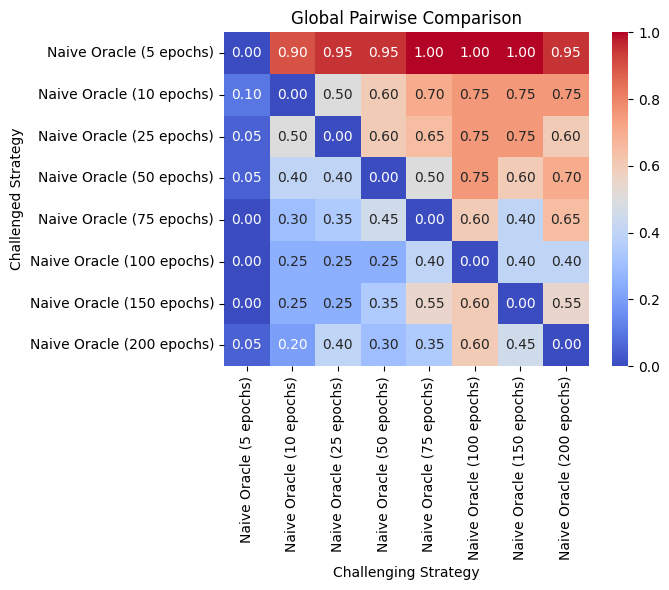

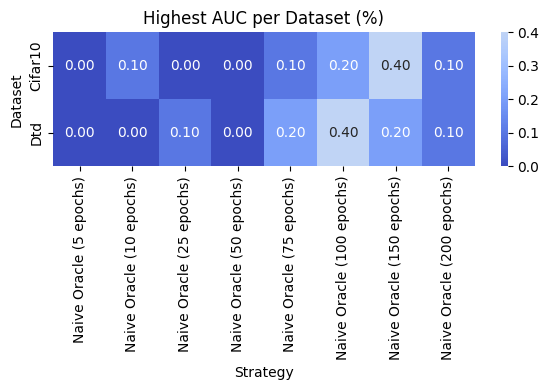

In [7]:
strategies = [qs for qs in query_strategies if "Naive Oracle (" in qs and " epochs)" in qs]
Labels = strategies
dsets = ['cifar10', 'dtd']
baseline = "Naive Oracle (200 epochs)"

res_dic = plot_learning_curves(all_acc_curves_strategies, strats=strategies, dsets=dsets, datasets=datasets, query_strategies=query_strategies, nrows=1, ncols=2, figsize=(11, 4), baseline=baseline, legend_dist=1.11)
final_acc_rel, auc_values_rel, final_acc_abs, auc_values_abs = res_dic['acc_rel'], res_dic['auc_rel'], res_dic['acc_abs'], res_dic['auc_abs']

print('##################################### Final Test-Accuracies (Relative to Random) #####################################')
df = pd.DataFrame(final_acc_rel)
random_row = pd.IndexSlice[df.index[df.index == baseline], :]
s = df.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s)

print('##################################### Test-AUCs (Relative to Random) #####################################')
df2 = pd.DataFrame(auc_values_rel)
random_row = pd.IndexSlice[df.index[df.index == baseline], :]
s2 = df2.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s2)

plot_global_pairwise_comparison(all_acc_curves_strategies, dsets, strategies, figsize=(7,6), Labels=Labels)
plot_global_comparison(all_acc_curves_strategies, dsets, strategies, figsize=(6,4), Labels=Labels)

## ACQ Size

In [8]:
experiment_name = 'abl_acq_size_new'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 2 * 10 * 4)) # n_dsets * n_seeds * n_acq_sizes

for run in runs_strategies:
    if 'al.strategy' in run.data.params: # This sorts out weird empty runs in the db file
        acq_size = {'5':'S', '10': 'M', '20': 'L', '25':'S', '40':'XL', '50':'M', '100':'L', '200':'XL'}[run.data.params['al.acq_size']]
        key = f'Naive Oracle (acq_size='+acq_size+')'
        all_acc_curves_strategies, query_times, all_pick_choices = retrieve_data(all_acc_curves_strategies, query_times, all_pick_choices, client, run, key, sampling_strategies, get_pick_choices=True)

##################################### abl_acq_size_new #####################################
Found 70 experiments for abl_acq_size_new with expected 80 experiments.


In [9]:
dsets = ['cifar10', 'dtd']
baseline = "Naive Oracle (acq_size=S)"
new_accs = {}
auc_values_abs = {}

for dset in dsets:
    new_accs[dset] = {}
    auc_values_abs[dset] = {}
    for i, acq_size in enumerate(['S', 'M', 'L', 'XL']):
        if (dset, acq_size) != ('dtd', 'XL'):
            step_size = [8, 4, 2, 1][i]
            strat = f'Naive Oracle (acq_size='+acq_size+')'
            accs_reduced = [[accs[j] for j in range(len(accs)) if j % step_size == 0] for accs in list(all_acc_curves_strategies[dset][strat].values())]
            auc_mean = np.mean(accs_reduced)
            auc_std = np.std(np.mean(accs_reduced, axis=1)) / np.sqrt(np.mean(accs_reduced, axis=1).shape[0])
            auc_values_abs[dset][strat] = str((auc_mean).round(4)) + '+/-' + str(auc_std.round(4))
            new_accs[dset][strat] = accs_reduced
        else:
            strat = f'Naive Oracle (acq_size='+acq_size+')'
            auc_values_abs[dset][strat] = "N.A."
    rand_accs_reduced = [[accs[j] for j in range(len(accs)) if j % 4 == 0] for accs in list(all_acc_curves_strategies[dset][baseline].values())]
    new_accs[dset][baseline] = rand_accs_reduced

print('##################################### Test-AUCs (Absolute) #####################################')
df2 = pd.DataFrame(auc_values_abs)
random_row = pd.IndexSlice[df.index[df.index == baseline], :]
s2 = df2.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s2)

##################################### Test-AUCs (Absolute) #####################################


,cifar10,dtd
Naive Oracle (acq_size=S),0.8472+/-0.003,0.6701+/-0.0019
Naive Oracle (acq_size=M),0.8426+/-0.0032,0.6619+/-0.0019
Naive Oracle (acq_size=L),0.8402+/-0.0034,0.6578+/-0.0018
Naive Oracle (acq_size=XL),0.8333+/-0.0035,N.A.


### Interpretation

While the smalles acq_size S is the best, we choose M for reasons of efficiency while maintaining high performance.

## Performance Estimation

In [10]:
experiment_name = 'abl_perf_est_25'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 2 * 10 * 3)) # n_dsets * n_seeds * n_loss_fn

for run in runs_strategies:
    if 'al.strategy' in run.data.params: # This sorts out weird empty runs in the db file
        key = f'Naive Oracle (perf_est='+run.data.params['al.optimal.loss']+')'
        all_acc_curves_strategies, query_times, all_pick_choices = retrieve_data(all_acc_curves_strategies, query_times, all_pick_choices, client, run, key, sampling_strategies, get_pick_choices=True)

##################################### abl_perf_est_25 #####################################
Found 60 experiments for abl_perf_est_25 with expected 60 experiments.


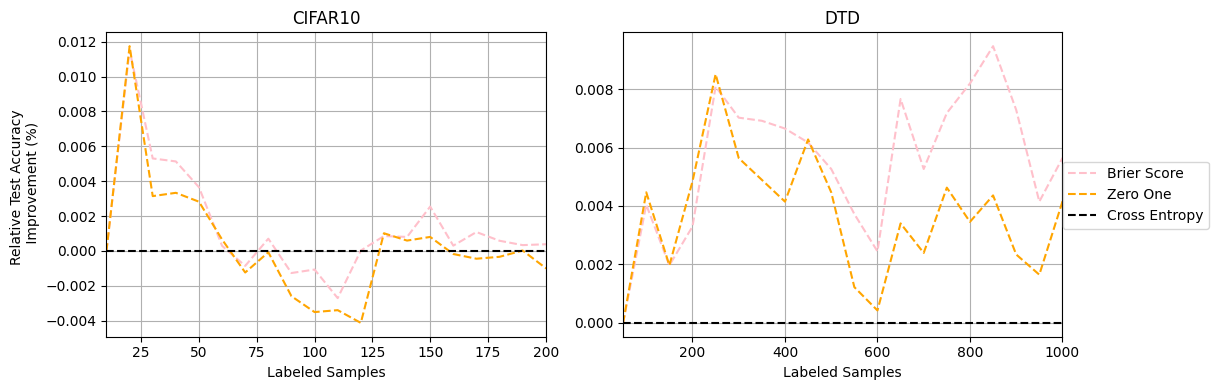

##################################### Final Test-Accuracies (Relative to Random) #####################################


,cifar10,dtd
Naive Oracle (perf_est=cross_entropy),94.57+/-0.05,77.38+/-0.17
Naive Oracle (perf_est=brier),0.04+/-0.05,0.24+/-0.16
Naive Oracle (perf_est=zero_one),-0.04+/-0.04,0.08+/-0.11


##################################### Test-AUCs (Relative to Random) #####################################


,cifar10,dtd
Naive Oracle (perf_est=cross_entropy),0.8842+/-0.0021,0.6876+/-0.0014
Naive Oracle (perf_est=brier),0.0013+/-0.0014,0.0054+/-0.0016
Naive Oracle (perf_est=zero_one),0.0003+/-0.0015,0.0035+/-0.0012


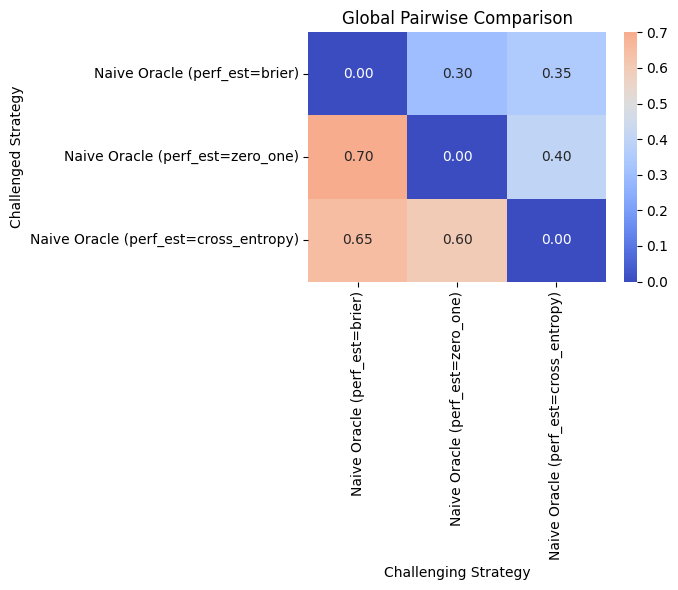

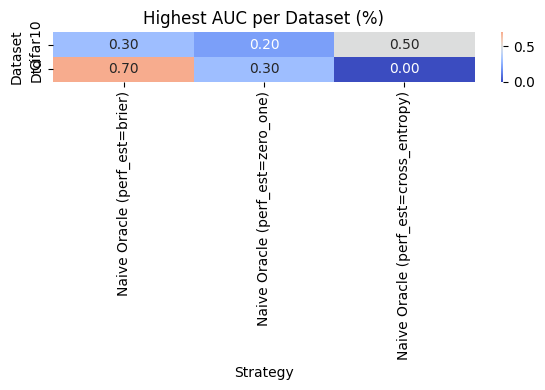

In [11]:
strategies = [qs for qs in query_strategies if "Naive Oracle (perf_est=" in qs]
Labels = strategies
dsets = ['cifar10', 'dtd']
baseline = "Naive Oracle (perf_est=cross_entropy)"

res_dic = plot_learning_curves(all_acc_curves_strategies, strats=strategies, dsets=dsets, datasets=datasets, query_strategies=query_strategies, nrows=1, ncols=2, figsize=(11, 4), baseline=baseline, legend_dist=1.11)
final_acc_rel, auc_values_rel, final_acc_abs, auc_values_abs = res_dic['acc_rel'], res_dic['auc_rel'], res_dic['acc_abs'], res_dic['auc_abs']

print('##################################### Final Test-Accuracies (Relative to Random) #####################################')
df = pd.DataFrame(final_acc_rel)
random_row = pd.IndexSlice[df.index[df.index == baseline], :]
s = df.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s)

print('##################################### Test-AUCs (Relative to Random) #####################################')
df2 = pd.DataFrame(auc_values_rel)
random_row = pd.IndexSlice[df.index[df.index == baseline], :]
s2 = df2.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s2)

plot_global_pairwise_comparison(all_acc_curves_strategies, dsets, strategies, figsize=(7,6), Labels=Labels)
plot_global_comparison(all_acc_curves_strategies, dsets, strategies, figsize=(6,4), Labels=Labels)

### Interpretation

While there are no significant differences, Brier Score does show a small tendency to be better, resulting in our choice.

# Baselines with current Best

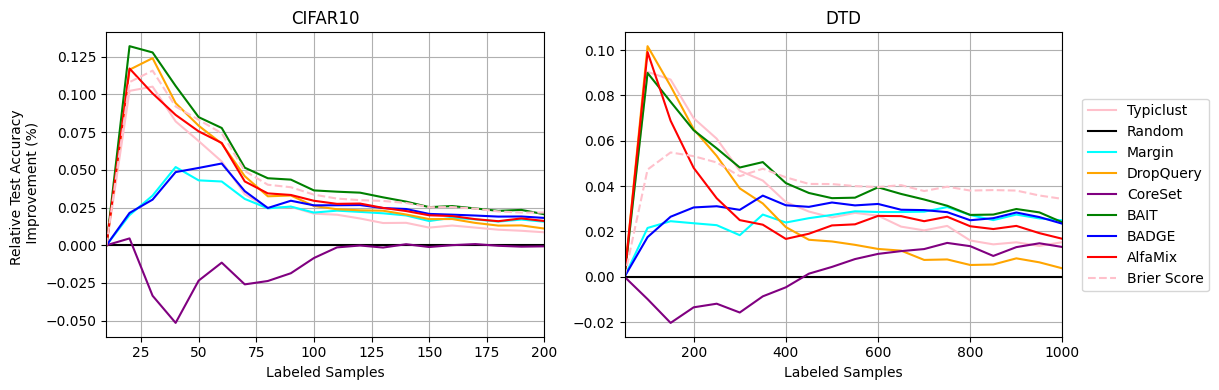

##################################### Test-AUCs (Relative to Random) #####################################


,cifar10,dtd
random,0.842+/-0.0042,0.653+/-0.0018
typiclust,0.0314+/-0.0025,0.033+/-0.0015
margin,0.0235+/-0.0034,0.0245+/-0.0019
dropquery,0.0384+/-0.0013,0.0246+/-0.0012
coreset,-0.0093+/-0.0068,0.0025+/-0.002
bait,0.0475+/-0.0021,0.0397+/-0.0013
badge,0.0266+/-0.0034,0.0271+/-0.0019
alfamix,0.0387+/-0.0021,0.0286+/-0.0017
Naive Oracle (perf_est=brier),0.0435+/-0.0014,0.0399+/-0.0016


In [12]:
strategies = ['random', 'margin', 'alfamix', 'badge', 'bait', 'dropquery', 'coreset', 'typiclust', 'Naive Oracle (perf_est=brier)']
Labels = strategies
dsets = ['cifar10', 'dtd']
baseline = "random"

res_dic = plot_learning_curves(all_acc_curves_strategies, strats=strategies, dsets=dsets, datasets=datasets, query_strategies=query_strategies, nrows=1, ncols=2, figsize=(11, 4), baseline=baseline, legend_dist=1.11)
final_acc_rel, auc_values_rel, final_acc_abs, auc_values_abs = res_dic['acc_rel'], res_dic['auc_rel'], res_dic['acc_abs'], res_dic['auc_abs']

print('##################################### Test-AUCs (Relative to Random) #####################################')
df2 = pd.DataFrame(auc_values_rel)
random_row = pd.IndexSlice[df.index[df.index == baseline], :]
s2 = df2.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s2)

# Selection Strategies

The second part of experiments investigates how the oracle generates batches to investigate. We investigate two variants and vary the number of batches.

Oracle_Variants = [Naive, BoSS]

Batch_Sizes = [11, 55, 110]

In [13]:
experiment_name = 'abl_num_batches'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 2 * 10 * 4 * 2)) # n_dsets * n_seeds * n_batches * n_selection_types

for run in runs_strategies:
    if 'al.strategy' in run.data.params: # This sorts out weird empty runs in the db file
        n_bat = run.data.params['al.optimal.num_batches']
        key = ('lazy+vary' if 'typiclust' in run.data.params['al.optimal.strategies'] else 'naive') + f' oracle({n_bat})'
        all_acc_curves_strategies, query_times, all_pick_choices = retrieve_data(all_acc_curves_strategies, query_times, all_pick_choices, client, run, key, sampling_strategies, get_pick_choices=True)

##################################### abl_num_batches #####################################
Found 165 experiments for abl_num_batches with expected 160 experiments.


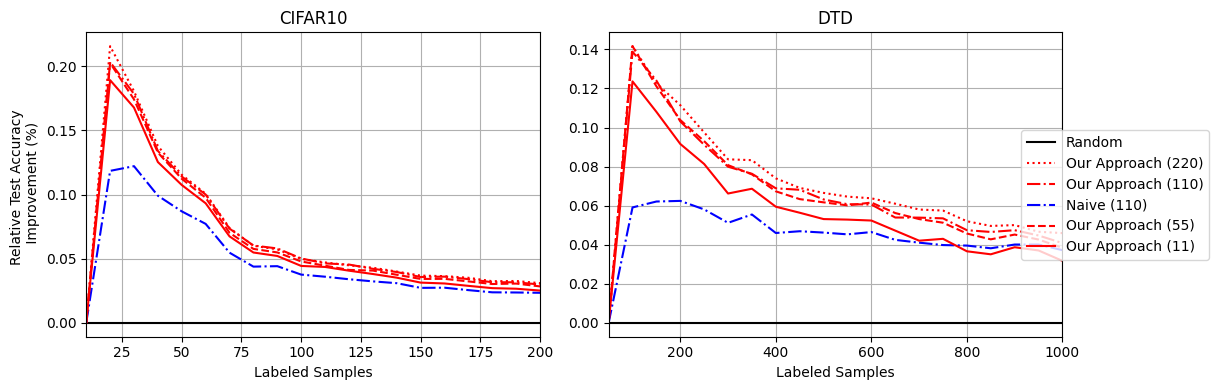

##################################### Final Test-Accuracies (Relative to Random) #####################################


,cifar10,dtd
random,92.48+/-0.31,74.37+/-0.19
lazy+vary oracle(220),3.02+/-0.05,4.3+/-0.13
lazy+vary oracle(110),2.99+/-0.04,3.87+/-0.1
naive oracle(110),2.3+/-0.05,3.77+/-0.15
lazy+vary oracle(55),2.83+/-0.04,3.71+/-0.13
lazy+vary oracle(11),2.52+/-0.06,2.81+/-0.13


##################################### Test-AUCs (Relative to Random) #####################################


,cifar10,dtd
random,0.842+/-0.0042,0.653+/-0.0018
lazy+vary oracle(220),0.0667+/-0.0015,0.0687+/-0.0009
lazy+vary oracle(110),0.0655+/-0.0011,0.0649+/-0.001
naive oracle(110),0.0472+/-0.0017,0.0446+/-0.001
lazy+vary oracle(55),0.0635+/-0.0013,0.064+/-0.0009
lazy+vary oracle(11),0.0598+/-0.0013,0.0549+/-0.0013


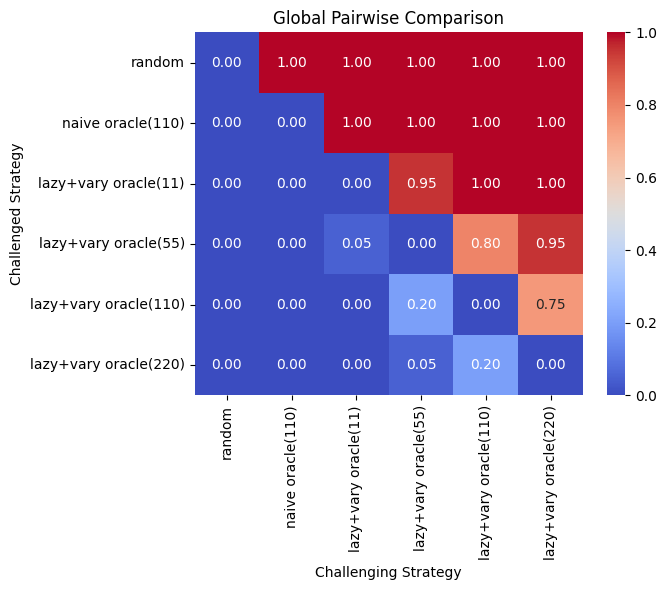

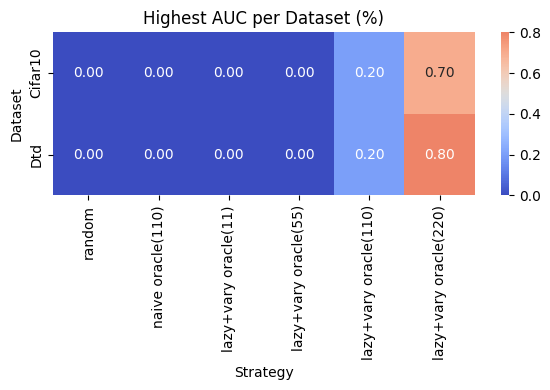

In [14]:
#strategies = ['random', 'naive oracle(11)', 'naive oracle(55)', 'naive oracle(110)', 'naive oracle(220)', 'lazy+vary oracle(11)', 'lazy+vary oracle(55)', 'lazy+vary oracle(110)', 'lazy+vary oracle(220)']
strategies = ['random', 'naive oracle(110)', 'lazy+vary oracle(11)',  'lazy+vary oracle(55)', 'lazy+vary oracle(110)', 'lazy+vary oracle(220)']

Labels = strategies
dsets = ['cifar10', 'dtd']
baseline = "random"

res_dic = plot_learning_curves(all_acc_curves_strategies, strats=strategies, dsets=dsets, datasets=datasets, query_strategies=query_strategies, nrows=1, ncols=2, figsize=(11, 4), baseline=baseline, legend_dist=1.11)
final_acc_rel, auc_values_rel, final_acc_abs, auc_values_abs = res_dic['acc_rel'], res_dic['auc_rel'], res_dic['acc_abs'], res_dic['auc_abs']

print('##################################### Final Test-Accuracies (Relative to Random) #####################################')
df = pd.DataFrame(final_acc_rel)
random_row = pd.IndexSlice[df.index[df.index == baseline], :]
s = df.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s)

print('##################################### Test-AUCs (Relative to Random) #####################################')
df2 = pd.DataFrame(auc_values_rel)
random_row = pd.IndexSlice[df.index[df.index == baseline], :]
s2 = df2.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s2)

plot_global_pairwise_comparison(all_acc_curves_strategies, dsets, strategies, figsize=(7,6), Labels=Labels)
plot_global_comparison(all_acc_curves_strategies, dsets, strategies, figsize=(6,4), Labels=Labels)

# Pick Choices

Lets investigate how the oracle makes use of its selection strategies and which strategies are picked most often.

In [ ]:
plot_avg_pick_choices_dset(all_pick_choices, strat='lazy+vary oracle(55)', dsets=['cifar10', 'dtd'], sampling_strategies=sampling_strategies)
plot_avg_pick_choices(all_pick_choices, fig_strats=['lazy+vary oracle(55)'], fig_dsets=['cifar10', 'dtd'], sampling_strategies=sampling_strategies, figsize=(2, 5))


In [6]:
experiment_name = 'abl_num_batches'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 2 * 10 * 4 * 2)) # n_dsets * n_seeds * n_batches * n_selection_types

for run in runs_strategies:
    if 'al.strategy' in run.data.params: # This sorts out weird empty runs in the db file
        n_bat = run.data.params['al.optimal.num_batches']
        key = ('lazy+vary' if 'typiclust' in run.data.params['al.optimal.strategies'] else 'naive') + f' oracle({n_bat})'
        if key == 'lazy+vary oracle(55)':
            key = 'Oracle (-0)'
            all_acc_curves_strategies, query_times, all_pick_choices = retrieve_data(all_acc_curves_strategies, query_times, all_pick_choices, client, run, key, sampling_strategies, get_pick_choices=True)

##################################### abl_num_batches #####################################
Found 165 experiments for abl_num_batches with expected 160 experiments.


In [5]:
experiment_name = 'abl_sel_strats_1'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 10 * 2)) # n_dsets * n_seeds

for run in runs_strategies:
    if 'al.strategy' in run.data.params: # This sorts out weird empty runs in the db file
        n_bat = run.data.params['al.optimal.num_batches']
        key = 'Oracle (-1)'
        all_acc_curves_strategies, query_times, all_pick_choices = retrieve_data(all_acc_curves_strategies, query_times, all_pick_choices, client, run, key, sampling_strategies, get_pick_choices=True)

##################################### abl_sel_strats_1 #####################################
Found 20 experiments for abl_sel_strats_1 with expected 20 experiments.


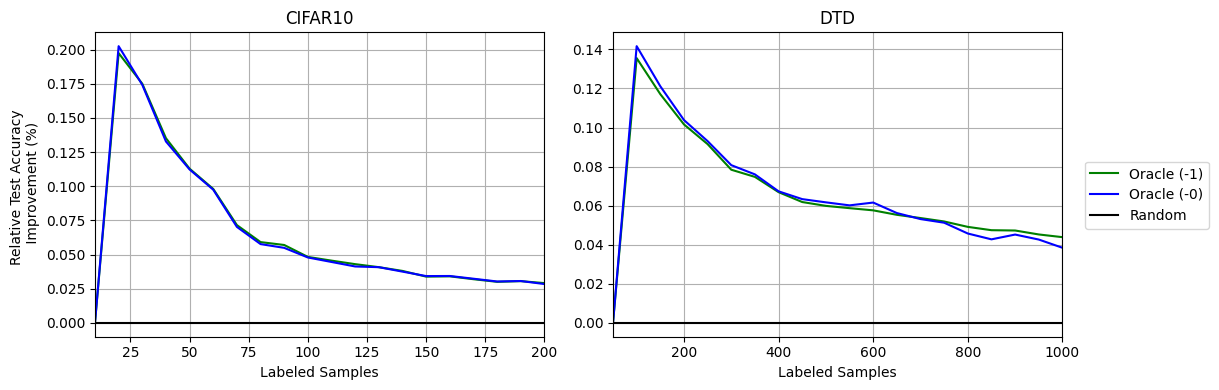

##################################### Final Test-Accuracies (Relative to Random) #####################################


,cifar10,dtd
random,92.48+/-0.31,74.37+/-0.19
Oracle (-1),2.8+/-0.05,4.09+/-0.09
Oracle (-0),2.83+/-0.04,3.71+/-0.13


##################################### Test-AUCs (Relative to Random) #####################################


,cifar10,dtd
random,0.842+/-0.0042,0.653+/-0.0018
Oracle (-1),0.0638+/-0.001,0.0637+/-0.0009
Oracle (-0),0.0635+/-0.0013,0.064+/-0.0009


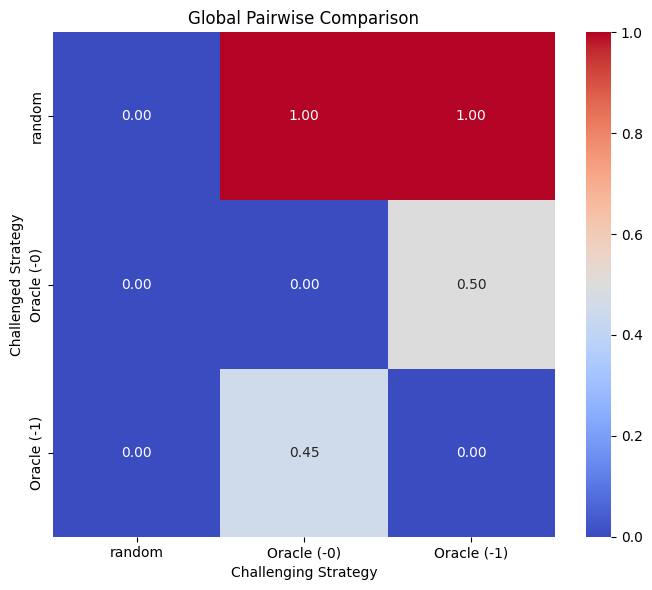

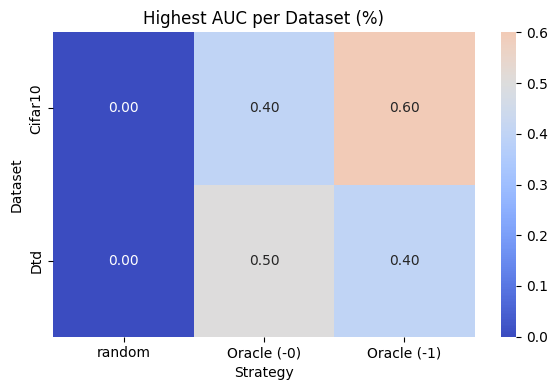

In [8]:
strategies = ['random', 'Oracle (-0)', 'Oracle (-1)']
Labels = strategies
dsets = ['cifar10', 'dtd']
baseline = "random"

res_dic = plot_learning_curves(all_acc_curves_strategies, strats=strategies, dsets=dsets, datasets=datasets, query_strategies=query_strategies, nrows=1, ncols=2, figsize=(11, 4), baseline=baseline, legend_dist=1.11)
final_acc_rel, auc_values_rel, final_acc_abs, auc_values_abs = res_dic['acc_rel'], res_dic['auc_rel'], res_dic['acc_abs'], res_dic['auc_abs']

print('##################################### Final Test-Accuracies (Relative to Random) #####################################')
df = pd.DataFrame(final_acc_rel)
random_row = pd.IndexSlice[df.index[df.index == baseline], :]
s = df.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s)

print('##################################### Test-AUCs (Relative to Random) #####################################')
df2 = pd.DataFrame(auc_values_rel)
random_row = pd.IndexSlice[df.index[df.index == baseline], :]
s2 = df2.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s2)

plot_global_pairwise_comparison(all_acc_curves_strategies, dsets, strategies, figsize=(7,6), Labels=Labels)
plot_global_comparison(all_acc_curves_strategies, dsets, strategies, figsize=(6,4), Labels=Labels)